In [2]:
# Cell 1: Installs (Kaggle — internet must be ON in notebook settings)
!pip install -q faiss-cpu transformers datasets sentence-transformers rank-bm25 sacrebleu accelerate evaluate

In [3]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for f in files[:3]:
        print("   ", f)

/kaggle/input
/kaggle/input/notebooks
/kaggle/input/notebooks/tanveerheir
/kaggle/input/notebooks/tanveerheir/rag-pipeline
    __results__.html
    __notebook__.ipynb
    __output__.json
/kaggle/input/notebooks/tanveerheir/rag-pipeline/dpr_rag_project
/kaggle/input/notebooks/tanveerheir/rag-pipeline/dpr_rag_project/squad
    val_pairs.json
    passages.json
    train_pairs.json
/kaggle/input/notebooks/tanveerheir/rag-pipeline/dpr_rag_project/squad/checkpoints
    passage_encoder_epoch1.pt
    question_encoder_final.pt
    passage_encoder_final.pt
/kaggle/input/notebooks/tanveerheir/rag-pipeline/dpr_rag_project/squad/results
    alpha_ablation.json
    hybrid_recall.json
    dense_recall.json
/kaggle/input/notebooks/tanveerheir/rag-pipeline/dpr_rag_project/squad/indexes
    faiss_index.bin
    passage_embeddings.npy
/kaggle/input/notebooks/tanveerheir/rag-pipeline/dpr_rag_project/triviaqa
    val_pairs.json
    passages.json
    train_pairs.json
/kaggle/input/notebooks/tanveerheir/rag-p

In [4]:
import shutil

SOURCE_DIR = "/kaggle/input/notebooks/tanveerheir/rag-pipeline/dpr_rag_project"
DEST_DIR = "/kaggle/working/dpr_rag_project"

os.makedirs(DEST_DIR, exist_ok=True)
shutil.copytree(SOURCE_DIR, DEST_DIR, dirs_exist_ok=True)

# Verify everything landed correctly
for root, dirs, files in os.walk(DEST_DIR):
    for f in files:
        full = os.path.join(root, f)
        print(full, f"({os.path.getsize(full)/1e6:.2f} MB)")

/kaggle/working/dpr_rag_project/triviaqa/train_pairs.json (17.34 MB)
/kaggle/working/dpr_rag_project/triviaqa/train_pairs_hard_neg.json (18.18 MB)
/kaggle/working/dpr_rag_project/triviaqa/val_pairs.json (0.50 MB)
/kaggle/working/dpr_rag_project/triviaqa/passages.json (26.83 MB)
/kaggle/working/dpr_rag_project/triviaqa/checkpoints/passage_encoder_epoch3.pt (438.02 MB)
/kaggle/working/dpr_rag_project/triviaqa/checkpoints/passage_encoder_hardneg_epoch1.pt (438.02 MB)
/kaggle/working/dpr_rag_project/triviaqa/checkpoints/passage_encoder_final.pt (438.01 MB)
/kaggle/working/dpr_rag_project/triviaqa/checkpoints/question_encoder_epoch1.pt (438.02 MB)
/kaggle/working/dpr_rag_project/triviaqa/checkpoints/passage_encoder_epoch2.pt (438.02 MB)
/kaggle/working/dpr_rag_project/triviaqa/checkpoints/question_encoder_final.pt (438.02 MB)
/kaggle/working/dpr_rag_project/triviaqa/checkpoints/question_encoder_hardneg_epoch1.pt (438.02 MB)
/kaggle/working/dpr_rag_project/triviaqa/checkpoints/passage_encode

In [5]:
# Cell 2: Imports & device
import os, json, random, time, re, string
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer, AutoModel,
    T5Tokenizer, T5ForConditionalGeneration,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset
import faiss
from rank_bm25 import BM25Okapi

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

Device: cuda
GPU: Tesla T4


In [6]:
# Cell 3: Working directories — separate subfolders per corpus, since we're training two retrievers

BASE_WORK_DIR = "/kaggle/working/dpr_rag_project"

def make_corpus_dirs(corpus_name):
    d = f"{BASE_WORK_DIR}/{corpus_name}"
    os.makedirs(f"{d}/checkpoints", exist_ok=True)
    os.makedirs(f"{d}/indexes", exist_ok=True)
    os.makedirs(f"{d}/results", exist_ok=True)
    return d

SQUAD_DIR = make_corpus_dirs("squad")
TRIVIAQA_DIR = make_corpus_dirs("triviaqa")

print("SQuAD work dir:", SQUAD_DIR)
print("TriviaQA work dir:", TRIVIAQA_DIR)

SQuAD work dir: /kaggle/working/dpr_rag_project/squad
TriviaQA work dir: /kaggle/working/dpr_rag_project/triviaqa


In [7]:
# Cell 4: Load SQuAD at larger scale, build passage corpus — skip if already saved

squad_passages_path = f"{SQUAD_DIR}/passages.json"
squad_train_path = f"{SQUAD_DIR}/train_pairs.json"
squad_val_path = f"{SQUAD_DIR}/val_pairs.json"

if os.path.exists(squad_passages_path) and os.path.exists(squad_train_path) and os.path.exists(squad_val_path):
    print(">>> [SQuAD] Found existing data splits — loading from disk instead of rebuilding.")
    with open(squad_passages_path) as f:
        squad_passages = json.load(f)
    with open(squad_train_path) as f:
        squad_train_pairs = json.load(f)
    with open(squad_val_path) as f:
        squad_val_pairs = json.load(f)
    print(f">>> [SQuAD] Loaded: {len(squad_passages)} passages | {len(squad_train_pairs)} train | {len(squad_val_pairs)} val")

else:
    print(">>> [SQuAD] No existing splits found — building from scratch.")
    print(">>> Loading SQuAD dataset...")
    raw_squad = load_dataset("rajpurkar/squad", split="train")
    print(f">>> Raw SQuAD examples available: {len(raw_squad)}")

    N_SQUAD = 87000  # full train set is ~87.6K
    raw_squad = raw_squad.shuffle(seed=SEED).select(range(min(N_SQUAD, len(raw_squad))))
    print(f">>> Using {len(raw_squad)} SQuAD examples")

    seen = {}
    squad_passages = []
    for ex in raw_squad:
        ctx = ex["context"]
        if ctx not in seen:
            pid = len(squad_passages)
            seen[ctx] = pid
            squad_passages.append({"id": pid, "text": ctx, "title": ex["title"]})

    squad_qa_pairs = []
    for ex in raw_squad:
        pid = seen[ex["context"]]
        squad_qa_pairs.append({
            "question": ex["question"],
            "pos_id": pid,
            "answers": ex["answers"]["text"]
        })

    print(f">>> SQuAD: {len(squad_passages)} unique passages, {len(squad_qa_pairs)} QA pairs")

    random.shuffle(squad_qa_pairs)
    n_val = 1500
    squad_val_pairs = squad_qa_pairs[:n_val]
    squad_train_pairs = squad_qa_pairs[n_val:]

    print(f">>> SQuAD train: {len(squad_train_pairs)} | val: {len(squad_val_pairs)}")

    with open(squad_passages_path, "w") as f: json.dump(squad_passages, f)
    with open(squad_train_path, "w") as f: json.dump(squad_train_pairs, f)
    with open(squad_val_path, "w") as f: json.dump(squad_val_pairs, f)
    print(">>> Saved SQuAD splits to disk")

>>> [SQuAD] Found existing data splits — loading from disk instead of rebuilding.
>>> [SQuAD] Loaded: 18890 passages | 85500 train | 1500 val


In [8]:
# Cell 5: Load TriviaQA, build passage corpus — skip if already saved

trivia_passages_path = f"{TRIVIAQA_DIR}/passages.json"
trivia_train_path = f"{TRIVIAQA_DIR}/train_pairs.json"
trivia_val_path = f"{TRIVIAQA_DIR}/val_pairs.json"

if os.path.exists(trivia_passages_path) and os.path.exists(trivia_train_path) and os.path.exists(trivia_val_path):
    print(">>> [TriviaQA] Found existing data splits — loading from disk instead of rebuilding.")
    with open(trivia_passages_path) as f:
        trivia_passages = json.load(f)
    with open(trivia_train_path) as f:
        trivia_train_pairs = json.load(f)
    with open(trivia_val_path) as f:
        trivia_val_pairs = json.load(f)
    print(f">>> [TriviaQA] Loaded: {len(trivia_passages)} passages | {len(trivia_train_pairs)} train | {len(trivia_val_pairs)} val")

else:
    print(">>> [TriviaQA] No existing splits found — building from scratch.")
    print(">>> Loading TriviaQA (rc.wikipedia subset)...")
    raw_trivia = load_dataset("mandarjoshi/trivia_qa", "rc.wikipedia", split="train")
    print(f">>> Raw TriviaQA examples available: {len(raw_trivia)}")

    N_TRIVIA = 40000
    raw_trivia = raw_trivia.shuffle(seed=SEED).select(range(min(N_TRIVIA, len(raw_trivia))))
    print(f">>> Using {len(raw_trivia)} TriviaQA examples")

    MAX_PASSAGE_WORDS = 200
    seen_t = {}
    trivia_passages = []
    trivia_qa_pairs = []
    skipped = 0

    for ex in raw_trivia:
        contexts = ex["entity_pages"]["wiki_context"]
        if not contexts or not contexts[0].strip():
            skipped += 1
            continue
        ctx = " ".join(contexts[0].split()[:MAX_PASSAGE_WORDS])
        if ctx not in seen_t:
            pid = len(trivia_passages)
            seen_t[ctx] = pid
            trivia_passages.append({"id": pid, "text": ctx, "title": ex["question_id"]})
        pid = seen_t[ctx]
        answer_aliases = ex["answer"]["aliases"] if ex["answer"]["aliases"] else [ex["answer"]["value"]]
        trivia_qa_pairs.append({
            "question": ex["question"],
            "pos_id": pid,
            "answers": answer_aliases
        })

    print(f">>> TriviaQA: {len(trivia_passages)} unique passages, {len(trivia_qa_pairs)} QA pairs ({skipped} skipped, no evidence)")

    random.shuffle(trivia_qa_pairs)
    n_val_t = 1000
    trivia_val_pairs = trivia_qa_pairs[:n_val_t]
    trivia_train_pairs = trivia_qa_pairs[n_val_t:]

    print(f">>> TriviaQA train: {len(trivia_train_pairs)} | val: {len(trivia_val_pairs)}")

    with open(trivia_passages_path, "w") as f: json.dump(trivia_passages, f)
    with open(trivia_train_path, "w") as f: json.dump(trivia_train_pairs, f)
    with open(trivia_val_path, "w") as f: json.dump(trivia_val_pairs, f)
    print(">>> Saved TriviaQA splits to disk")

>>> [TriviaQA] Found existing data splits — loading from disk instead of rebuilding.
>>> [TriviaQA] Loaded: 21111 passages | 39000 train | 1000 val


In [9]:
# Cell 6: Quick sanity check on both corpora before moving on

print("="*60)
print("SQuAD sample:")
print("Q:", squad_train_pairs[0]["question"])
print("Passage:", squad_passages[squad_train_pairs[0]["pos_id"]]["text"][:150], "...")
print("\nTriviaQA sample:")
print("Q:", trivia_train_pairs[0]["question"])
print("Passage:", trivia_passages[trivia_train_pairs[0]["pos_id"]]["text"][:150], "...")
print("="*60)

print(f"\nCorpus size comparison: SQuAD={len(squad_passages)} passages | TriviaQA={len(trivia_passages)} passages")

SQuAD sample:
Q: What character was Tom Kenny best known for portraying?
Passage: Each August, Turner Classic Movies suspends its regular schedule for a special month of film marathons called "Summer Under the Stars", which features ...

TriviaQA sample:
Q: The headquarters of which political party are in Newton Abbot, Devon?
Passage: Devon (; archaically known as Devonshire) is a county of England, reaching from the Bristol Channel in the north to the English Channel in the south.  ...

Corpus size comparison: SQuAD=18890 passages | TriviaQA=21111 passages


In [10]:
# Cell 7: Encoder architecture, dataset wrapper, in-batch negative loss
# This is shared code — we'll create separate encoder INSTANCES per corpus

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class Encoder(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]

class DPRDataset(Dataset):
    def __init__(self, qa_pairs, passages):
        self.qa_pairs = qa_pairs
        self.passages = passages
    def __len__(self):
        return len(self.qa_pairs)
    def __getitem__(self, idx):
        item = self.qa_pairs[idx]
        return item["question"], self.passages[item["pos_id"]]["text"]

def collate_fn(batch):
    questions, pos_texts = zip(*batch)
    return list(questions), list(pos_texts)

def in_batch_negative_loss(q_emb, p_emb, temperature=0.1):
    q_emb = F.normalize(q_emb, p=2, dim=1)
    p_emb = F.normalize(p_emb, p=2, dim=1)
    scores = torch.matmul(q_emb, p_emb.T) / temperature
    labels = torch.arange(scores.size(0), device=scores.device)
    loss = F.cross_entropy(scores, labels)
    return loss, scores

print(">>> Architecture, dataset, and loss function defined.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

>>> Architecture, dataset, and loss function defined.


In [11]:
# Cell 8: Reusable training function — works for any corpus, checkpoints after every epoch

BATCH_SIZE = 8
MAX_LEN_Q = 48
MAX_LEN_P = 160
EPOCHS = 3
LR = 2e-5
TEMP = 0.1

def train_dpr_for_corpus(corpus_name, work_dir, train_pairs, passages):
    """
    Trains a fresh question/passage encoder pair for one corpus.
    Saves a checkpoint after EVERY epoch (not just at the end), so a crash
    mid-training only costs the current epoch's progress, not the whole run.
    Skips training entirely if a final checkpoint already exists.
    """
    final_q_path = f"{work_dir}/checkpoints/question_encoder_final.pt"
    final_p_path = f"{work_dir}/checkpoints/passage_encoder_final.pt"

    question_encoder = Encoder().to(device)
    passage_encoder = Encoder().to(device)

    if os.path.exists(final_q_path) and os.path.exists(final_p_path):
        print(f">>> [{corpus_name}] Final checkpoint already exists — loading instead of training.")
        question_encoder.load_state_dict(torch.load(final_q_path, map_location=device))
        passage_encoder.load_state_dict(torch.load(final_p_path, map_location=device))
        return question_encoder, passage_encoder

    print(f">>> [{corpus_name}] No final checkpoint found. Checking for a partial (per-epoch) checkpoint...")

    # Check for the most recent epoch checkpoint to resume from
    start_epoch = 0
    for ep in range(EPOCHS, 0, -1):
        ep_q_path = f"{work_dir}/checkpoints/question_encoder_epoch{ep}.pt"
        ep_p_path = f"{work_dir}/checkpoints/passage_encoder_epoch{ep}.pt"
        if os.path.exists(ep_q_path) and os.path.exists(ep_p_path):
            print(f">>> [{corpus_name}] Found checkpoint at epoch {ep} — resuming from epoch {ep+1}.")
            question_encoder.load_state_dict(torch.load(ep_q_path, map_location=device))
            passage_encoder.load_state_dict(torch.load(ep_p_path, map_location=device))
            start_epoch = ep
            break

    if start_epoch == 0:
        print(f">>> [{corpus_name}] No partial checkpoint found — training from scratch.")

    train_dataset = DPRDataset(train_pairs, passages)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                               collate_fn=collate_fn, drop_last=True)

    params = list(question_encoder.parameters()) + list(passage_encoder.parameters())
    optimizer = torch.optim.AdamW(params, lr=LR)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )

    print(f">>> [{corpus_name}] Steps per epoch: {len(train_loader)} | Total steps: {total_steps}")
    print(f">>> [{corpus_name}] TRAINING STARTING NOW — this is the expensive step, expect ~20-60 min per epoch on T4.")

    overall_start = time.time()
    for epoch in range(start_epoch, EPOCHS):
        print(f"\n>>> [{corpus_name}] === Starting epoch {epoch+1}/{EPOCHS} ===")
        epoch_start = time.time()
        epoch_losses = []

        question_encoder.train()
        passage_encoder.train()

        for step, (questions, pos_texts) in enumerate(train_loader):
            q_enc = tokenizer(questions, padding=True, truncation=True, max_length=MAX_LEN_Q, return_tensors="pt")
            p_enc = tokenizer(pos_texts, padding=True, truncation=True, max_length=MAX_LEN_P, return_tensors="pt")

            q_emb = question_encoder(q_enc["input_ids"].to(device), q_enc["attention_mask"].to(device))
            p_emb = passage_encoder(p_enc["input_ids"].to(device), p_enc["attention_mask"].to(device))

            loss, _ = in_batch_negative_loss(q_emb, p_emb, temperature=TEMP)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            optimizer.step()
            scheduler.step()

            loss_val = loss.item()
            epoch_losses.append(loss_val)
            del q_emb, p_emb, loss

            if step % 100 == 0:
                elapsed_min = (time.time() - epoch_start) / 60
                print(f"    [{corpus_name}] Epoch {epoch+1}/{EPOCHS} | Step {step}/{len(train_loader)} | "
                      f"Loss: {loss_val:.4f} | Elapsed this epoch: {elapsed_min:.1f} min")

            if step % 300 == 0:
                torch.cuda.empty_cache()

        epoch_elapsed = (time.time() - epoch_start) / 60
        print(f">>> [{corpus_name}] Epoch {epoch+1} DONE | avg loss: {np.mean(epoch_losses):.4f} | time: {epoch_elapsed:.1f} min")

        # SAVE CHECKPOINT AFTER EVERY EPOCH — this is the key safety net
        ep_q_path = f"{work_dir}/checkpoints/question_encoder_epoch{epoch+1}.pt"
        ep_p_path = f"{work_dir}/checkpoints/passage_encoder_epoch{epoch+1}.pt"
        torch.save(question_encoder.state_dict(), ep_q_path)
        torch.save(passage_encoder.state_dict(), ep_p_path)
        print(f">>> [{corpus_name}] Saved epoch {epoch+1} checkpoint to disk.")

    total_elapsed = (time.time() - overall_start) / 60
    print(f"\n>>> [{corpus_name}] TRAINING COMPLETE. Total time: {total_elapsed:.1f} min")

    # Save final checkpoint (clean name, used by the skip-check at the top of this function)
    torch.save(question_encoder.state_dict(), final_q_path)
    torch.save(passage_encoder.state_dict(), final_p_path)
    print(f">>> [{corpus_name}] Saved FINAL checkpoint to disk.")

    return question_encoder, passage_encoder

print(">>> train_dpr_for_corpus() ready.")

>>> train_dpr_for_corpus() ready.


In [12]:
# Cell 9: Train (or resume/load) the SQuAD retriever
squad_question_encoder, squad_passage_encoder = train_dpr_for_corpus(
    "SQuAD", SQUAD_DIR, squad_train_pairs, squad_passages
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


>>> [SQuAD] Final checkpoint already exists — loading instead of training.


In [13]:
# Cell 10: Train (or resume/load) the TriviaQA retriever
trivia_question_encoder, trivia_passage_encoder = train_dpr_for_corpus(
    "TriviaQA", TRIVIAQA_DIR, trivia_train_pairs, trivia_passages
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


>>> [TriviaQA] Final checkpoint already exists — loading instead of training.


In [14]:
# Cell 11: Encode passage corpus for embedding-based retrieval — per corpus, skip if already done

def encode_corpus(encoder, passages, batch_size=32, max_len=160):
    encoder.eval()
    all_embeddings = []
    texts = [p["text"] for p in passages]
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            enc = tokenizer(batch_texts, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
            enc = {k: v.to(device) for k, v in enc.items()}
            emb = encoder(enc["input_ids"], enc["attention_mask"])
            all_embeddings.append(emb.cpu().numpy())
            if (i // batch_size) % 100 == 0:
                print(f"    Encoded {i}/{len(texts)} passages")
    return np.vstack(all_embeddings)

def get_or_build_embeddings(corpus_name, work_dir, passage_encoder, passages):
    emb_path = f"{work_dir}/indexes/passage_embeddings.npy"
    if os.path.exists(emb_path):
        print(f">>> [{corpus_name}] Found existing embeddings — loading from disk.")
        return np.load(emb_path)
    print(f">>> [{corpus_name}] No embeddings found — encoding {len(passages)} passages now...")
    start = time.time()
    embeddings = encode_corpus(passage_encoder, passages, batch_size=32)
    print(f">>> [{corpus_name}] Done in {(time.time()-start):.1f}s")
    np.save(emb_path, embeddings)
    print(f">>> [{corpus_name}] Saved embeddings to disk")
    return embeddings

squad_passage_embeddings = get_or_build_embeddings("SQuAD", SQUAD_DIR, squad_passage_encoder, squad_passages)
print("SQuAD embeddings shape:", squad_passage_embeddings.shape)

trivia_passage_embeddings = get_or_build_embeddings("TriviaQA", TRIVIAQA_DIR, trivia_passage_encoder, trivia_passages)
print("TriviaQA embeddings shape:", trivia_passage_embeddings.shape)

>>> [SQuAD] Found existing embeddings — loading from disk.
SQuAD embeddings shape: (18890, 768)
>>> [TriviaQA] Found existing embeddings — loading from disk.
TriviaQA embeddings shape: (21111, 768)


In [15]:
# Cell 12: Build FAISS index per corpus

def get_or_build_faiss_index(corpus_name, work_dir, embeddings):
    index_path = f"{work_dir}/indexes/faiss_index.bin"
    if os.path.exists(index_path):
        print(f">>> [{corpus_name}] Found existing FAISS index — loading from disk.")
        return faiss.read_index(index_path)
    print(f">>> [{corpus_name}] Building FAISS index...")
    embedding_dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(embedding_dim)
    embeddings = embeddings.astype("float32")
    index.add(embeddings)
    faiss.write_index(index, index_path)
    print(f">>> [{corpus_name}] Saved FAISS index to disk ({index.ntotal} vectors)")
    return index

squad_index = get_or_build_faiss_index("SQuAD", SQUAD_DIR, squad_passage_embeddings)
trivia_index = get_or_build_faiss_index("TriviaQA", TRIVIAQA_DIR, trivia_passage_embeddings)

print("SQuAD index size:", squad_index.ntotal)
print("TriviaQA index size:", trivia_index.ntotal)

>>> [SQuAD] Found existing FAISS index — loading from disk.
>>> [TriviaQA] Found existing FAISS index — loading from disk.
SQuAD index size: 18890
TriviaQA index size: 21111


In [16]:
# Cell 13: BM25 index per corpus — fast to rebuild, not saved to disk

def simple_tokenize(text):
    return text.lower().split()

squad_tokenized = [simple_tokenize(p["text"]) for p in squad_passages]
squad_bm25 = BM25Okapi(squad_tokenized)
print(">>> SQuAD BM25 index built:", len(squad_tokenized), "passages")

trivia_tokenized = [simple_tokenize(p["text"]) for p in trivia_passages]
trivia_bm25 = BM25Okapi(trivia_tokenized)
print(">>> TriviaQA BM25 index built:", len(trivia_tokenized), "passages")

>>> SQuAD BM25 index built: 18890 passages
>>> TriviaQA BM25 index built: 21111 passages


In [17]:
# Cell 14: Generic retrieval functions that work for either corpus

def dense_retrieve(question, question_encoder, index, passages, max_len_q=48, k=5):
    question_encoder.eval()
    with torch.no_grad():
        enc = tokenizer([question], padding=True, truncation=True, max_length=max_len_q, return_tensors="pt")
        enc = {k_: v.to(device) for k_, v in enc.items()}
        q_emb = question_encoder(enc["input_ids"], enc["attention_mask"])
        q_emb = q_emb.cpu().numpy().astype("float32")
    scores, indices = index.search(q_emb, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({"passage_id": int(idx), "text": passages[idx]["text"], "score": float(score)})
    return results

def normalize_scores(scores):
    scores = np.array(scores)
    if scores.max() == scores.min():
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

def hybrid_retrieve(question, question_encoder, index, passages, bm25, k=5, alpha=0.5,
                     dense_candidates=100, bm25_candidates=100, max_len_q=48):
    dense_results = dense_retrieve(question, question_encoder, index, passages, max_len_q, k=dense_candidates)
    dense_ids = [r["passage_id"] for r in dense_results]
    dense_scores_map = {r["passage_id"]: r["score"] for r in dense_results}

    bm25_scores_all = bm25.get_scores(simple_tokenize(question))
    bm25_top_idx = np.argsort(bm25_scores_all)[::-1][:bm25_candidates]
    bm25_scores_map = {int(idx): float(bm25_scores_all[idx]) for idx in bm25_top_idx}

    candidate_ids = list(set(dense_ids) | set(bm25_scores_map.keys()))
    dense_vals = [dense_scores_map.get(pid, 0.0) for pid in candidate_ids]
    bm25_vals = [bm25_scores_map.get(pid, 0.0) for pid in candidate_ids]

    dense_norm = normalize_scores(dense_vals)
    bm25_norm = normalize_scores(bm25_vals)
    combined = alpha * dense_norm + (1 - alpha) * bm25_norm

    ranked = sorted(zip(candidate_ids, combined), key=lambda x: x[1], reverse=True)[:k]
    return [{"passage_id": pid, "text": passages[pid]["text"], "score": float(score)} for pid, score in ranked]

print(">>> Retrieval functions ready (generic, work for any corpus via parameters).")

>>> Retrieval functions ready (generic, work for any corpus via parameters).


In [18]:
# Cell 15: Quick sanity check — one example per corpus, dense vs hybrid

print("="*70)
print("SQuAD example:")
sq_test = squad_val_pairs[0]
print("Q:", sq_test["question"])
sq_dense = dense_retrieve(sq_test["question"], squad_question_encoder, squad_index, squad_passages, k=3)
sq_hybrid = hybrid_retrieve(sq_test["question"], squad_question_encoder, squad_index, squad_passages, squad_bm25, k=3)
print("Dense top-1:", sq_dense[0]["text"][:100], "...")
print("Hybrid top-1:", sq_hybrid[0]["text"][:100], "...")
print("Gold:", squad_passages[sq_test["pos_id"]]["text"][:100], "...")

print("\n" + "="*70)
print("TriviaQA example:")
tq_test = trivia_val_pairs[0]
print("Q:", tq_test["question"])
tq_dense = dense_retrieve(tq_test["question"], trivia_question_encoder, trivia_index, trivia_passages, k=3)
tq_hybrid = hybrid_retrieve(tq_test["question"], trivia_question_encoder, trivia_index, trivia_passages, trivia_bm25, k=3)
print("Dense top-1:", tq_dense[0]["text"][:100], "...")
print("Hybrid top-1:", tq_hybrid[0]["text"][:100], "...")
print("Gold:", trivia_passages[tq_test["pos_id"]]["text"][:100], "...")
print("="*70)

SQuAD example:
Q: When was the Casas Adobes Plaza established?
Dense top-1: Also of major note in Ciudad Vieja is the Plaza de la Constitución (or Plaza Matriz). During the fir ...
Hybrid top-1: The community of Casas Adobes is also on the Northwest Side, with the distinction of being Tucson's  ...
Gold: The community of Casas Adobes is also on the Northwest Side, with the distinction of being Tucson's  ...

TriviaQA example:
Q: Which unit of measurement is defined as being exactly 1,852 metres ?
Dense top-1: A unit of measurement is a definite magnitude of a quantity, defined and adopted by convention or by ...
Hybrid top-1: A unit of measurement is a definite magnitude of a quantity, defined and adopted by convention or by ...
Gold: The metric system is an internationally agreed decimal system of measurement. It was originally base ...


In [19]:
# Cell 16: Dense-only Recall@k, both corpora — skip if already saved

def evaluate_recall_dense(qa_pairs, question_encoder, index, passages, k_values=[1, 5, 20, 100], max_len_q=48):
    max_k = max(k_values)
    hits = {k: 0 for k in k_values}
    for item in qa_pairs:
        retrieved = dense_retrieve(item["question"], question_encoder, index, passages, max_len_q, k=max_k)
        retrieved_ids = [r["passage_id"] for r in retrieved]
        for k in k_values:
            if item["pos_id"] in retrieved_ids[:k]:
                hits[k] += 1
    n = len(qa_pairs)
    return {k: hits[k] / n for k in k_values}

squad_dense_recall_path = f"{SQUAD_DIR}/results/dense_recall.json"
trivia_dense_recall_path = f"{TRIVIAQA_DIR}/results/dense_recall.json"

if os.path.exists(squad_dense_recall_path):
    print(">>> [SQuAD] Found existing dense_recall.json — loading.")
    with open(squad_dense_recall_path) as f:
        squad_dense_recall = {int(k): v for k, v in json.load(f).items()}
else:
    print(">>> [SQuAD] Evaluating dense-only Recall@k...")
    squad_dense_recall = evaluate_recall_dense(squad_val_pairs, squad_question_encoder, squad_index, squad_passages)
    print(squad_dense_recall)
    with open(squad_dense_recall_path, "w") as f:
        json.dump(squad_dense_recall, f, indent=2)
    print(">>> [SQuAD] Saved")

if os.path.exists(trivia_dense_recall_path):
    print(">>> [TriviaQA] Found existing dense_recall.json — loading.")
    with open(trivia_dense_recall_path) as f:
        trivia_dense_recall = {int(k): v for k, v in json.load(f).items()}
else:
    print(">>> [TriviaQA] Evaluating dense-only Recall@k...")
    trivia_dense_recall = evaluate_recall_dense(trivia_val_pairs, trivia_question_encoder, trivia_index, trivia_passages)
    print(trivia_dense_recall)
    with open(trivia_dense_recall_path, "w") as f:
        json.dump(trivia_dense_recall, f, indent=2)
    print(">>> [TriviaQA] Saved")

>>> [SQuAD] Found existing dense_recall.json — loading.
>>> [TriviaQA] Found existing dense_recall.json — loading.


In [20]:
# Cell 17: Hybrid Recall@k (alpha=0.5), both corpora — skip if already saved

def evaluate_recall_hybrid(qa_pairs, question_encoder, index, passages, bm25, k_values=[1, 5, 20, 100], alpha=0.5, max_len_q=48):
    max_k = max(k_values)
    hits = {k: 0 for k in k_values}
    for item in qa_pairs:
        retrieved = hybrid_retrieve(item["question"], question_encoder, index, passages, bm25,
                                     k=max_k, alpha=alpha, max_len_q=max_len_q)
        retrieved_ids = [r["passage_id"] for r in retrieved]
        for k in k_values:
            if item["pos_id"] in retrieved_ids[:k]:
                hits[k] += 1
    n = len(qa_pairs)
    return {k: hits[k] / n for k in k_values}

squad_hybrid_recall_path = f"{SQUAD_DIR}/results/hybrid_recall.json"
trivia_hybrid_recall_path = f"{TRIVIAQA_DIR}/results/hybrid_recall.json"

if os.path.exists(squad_hybrid_recall_path):
    print(">>> [SQuAD] Found existing hybrid_recall.json — loading.")
    with open(squad_hybrid_recall_path) as f:
        squad_hybrid_recall = {int(k): v for k, v in json.load(f).items()}
else:
    print(">>> [SQuAD] Evaluating hybrid Recall@k...")
    squad_hybrid_recall = evaluate_recall_hybrid(squad_val_pairs, squad_question_encoder, squad_index, squad_passages, squad_bm25)
    print(squad_hybrid_recall)
    with open(squad_hybrid_recall_path, "w") as f:
        json.dump(squad_hybrid_recall, f, indent=2)
    print(">>> [SQuAD] Saved")

if os.path.exists(trivia_hybrid_recall_path):
    print(">>> [TriviaQA] Found existing hybrid_recall.json — loading.")
    with open(trivia_hybrid_recall_path) as f:
        trivia_hybrid_recall = {int(k): v for k, v in json.load(f).items()}
else:
    print(">>> [TriviaQA] Evaluating hybrid Recall@k...")
    trivia_hybrid_recall = evaluate_recall_hybrid(trivia_val_pairs, trivia_question_encoder, trivia_index, trivia_passages, trivia_bm25)
    print(trivia_hybrid_recall)
    with open(trivia_hybrid_recall_path, "w") as f:
        json.dump(trivia_hybrid_recall, f, indent=2)
    print(">>> [TriviaQA] Saved")

print("\n=== Dense vs Hybrid comparison ===")
print(f"{'Corpus':<10}{'k':<6}{'Dense':<10}{'Hybrid':<10}")
for corpus_name, dense_r, hybrid_r in [("SQuAD", squad_dense_recall, squad_hybrid_recall),
                                          ("TriviaQA", trivia_dense_recall, trivia_hybrid_recall)]:
    for k in [1, 5, 20, 100]:
        print(f"{corpus_name:<10}{k:<6}{dense_r[k]:<10.4f}{hybrid_r[k]:<10.4f}")

>>> [SQuAD] Found existing hybrid_recall.json — loading.
>>> [TriviaQA] Found existing hybrid_recall.json — loading.

=== Dense vs Hybrid comparison ===
Corpus    k     Dense     Hybrid    
SQuAD     1     0.3773    0.5873    
SQuAD     5     0.6380    0.7847    
SQuAD     20    0.8127    0.8967    
SQuAD     100   0.9353    0.9540    
TriviaQA  1     0.5740    0.5140    
TriviaQA  5     0.7670    0.7270    
TriviaQA  20    0.8600    0.8710    
TriviaQA  100   0.9400    0.9400    


In [21]:
# Cell 18: Alpha ablation, both corpora — skip if already saved

alphas_to_try = [0.0, 0.3, 0.5, 0.7, 1.0]

def run_ablation(corpus_name, qa_pairs, question_encoder, index, passages, bm25):
    results = {}
    for alpha in alphas_to_try:
        start = time.time()
        recall = evaluate_recall_hybrid(qa_pairs, question_encoder, index, passages, bm25, alpha=alpha)
        elapsed = time.time() - start
        results[alpha] = recall
        print(f"[{corpus_name}] alpha={alpha:.1f} | R@1={recall[1]:.4f} | R@5={recall[5]:.4f} | "
              f"R@20={recall[20]:.4f} | R@100={recall[100]:.4f} | ({elapsed:.1f}s)")
    return results

squad_ablation_path = f"{SQUAD_DIR}/results/alpha_ablation.json"
trivia_ablation_path = f"{TRIVIAQA_DIR}/results/alpha_ablation.json"

if os.path.exists(squad_ablation_path):
    print(">>> [SQuAD] Found existing alpha_ablation.json — loading.")
    with open(squad_ablation_path) as f:
        squad_ablation = json.load(f)
else:
    print(">>> [SQuAD] Running alpha ablation...")
    squad_ablation = run_ablation("SQuAD", squad_val_pairs, squad_question_encoder, squad_index, squad_passages, squad_bm25)
    with open(squad_ablation_path, "w") as f:
        json.dump(squad_ablation, f, indent=2)
    print(">>> [SQuAD] Saved")

if os.path.exists(trivia_ablation_path):
    print(">>> [TriviaQA] Found existing alpha_ablation.json — loading.")
    with open(trivia_ablation_path) as f:
        trivia_ablation = json.load(f)
else:
    print(">>> [TriviaQA] Running alpha ablation...")
    trivia_ablation = run_ablation("TriviaQA", trivia_val_pairs, trivia_question_encoder, trivia_index, trivia_passages, trivia_bm25)
    with open(trivia_ablation_path, "w") as f:
        json.dump(trivia_ablation, f, indent=2)
    print(">>> [TriviaQA] Saved")

>>> [SQuAD] Found existing alpha_ablation.json — loading.
>>> [TriviaQA] Found existing alpha_ablation.json — loading.


In [22]:
# Cell 19: Load T5-base for generation (shared across both corpora)
GEN_MODEL_NAME = "t5-base"
gen_tokenizer = T5Tokenizer.from_pretrained(GEN_MODEL_NAME)
generator = T5ForConditionalGeneration.from_pretrained(GEN_MODEL_NAME).to(device)
print(">>> T5-base loaded:", sum(p.numel() for p in generator.parameters())/1e6, "M params")

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

>>> T5-base loaded: 222.903552 M params


In [23]:
# Cell 20: Generic FiD-style input construction
def build_fid_input(question, retrieved_passages):
    context_block = " ".join([f"context: {p['text']}" for p in retrieved_passages])
    return f"question: {question} {context_block}"

print(">>> build_fid_input() ready.")

>>> build_fid_input() ready.


In [24]:
# Cell 21: Generic answer generation, takes a retrieve_fn so it works for either corpus

def generate_answer(question, retrieve_fn, k=3, max_new_tokens=32):
    retrieved = retrieve_fn(question, k=k)
    fid_input = build_fid_input(question, retrieved)
    inputs = gen_tokenizer(fid_input, return_tensors="pt", truncation=True, max_length=512).to(device)
    generator.eval()
    with torch.no_grad():
        output_ids = generator.generate(
            inputs["input_ids"], attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens, num_beams=4, early_stopping=True
        )
    answer = gen_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return answer, retrieved

print(">>> generate_answer() ready.")

>>> generate_answer() ready.


In [25]:
# Cell 22: Qualitative comparison — SQuAD, dense vs hybrid

squad_dense_fn = lambda q, k: dense_retrieve(q, squad_question_encoder, squad_index, squad_passages, k=k)
squad_hybrid_fn = lambda q, k: hybrid_retrieve(q, squad_question_encoder, squad_index, squad_passages, squad_bm25, k=k, alpha=0.5)

print("="*70, "\nSQuAD qualitative examples\n" + "="*70)
for i in range(5):
    item = squad_val_pairs[i]
    d_ans, _ = generate_answer(item["question"], squad_dense_fn, k=3)
    h_ans, _ = generate_answer(item["question"], squad_hybrid_fn, k=3)
    print(f"\nQ: {item['question']}")
    print(f"Gold: {item['answers']}")
    print(f"Dense: {d_ans}")
    print(f"Hybrid: {h_ans}")

SQuAD qualitative examples

Q: When was the Casas Adobes Plaza established?
Gold: ['1948']
Dense: first decades of Uruguayan independence
Hybrid: 1948

Q: When was the Treaty of Wuchale signed?
Gold: ['1889']
Dense: 1889
Hybrid: 1889

Q: How did Spielberg influence the public's behavior?
Gold: ['many will think for a second before going into the water this summer']
Dense: futuristic science fiction episode
Hybrid: 46 different personality attributes

Q: What demarcates a clear distinction between nation and state, as well as religion and state?
Gold: ['Indian political philosophy']
Dense: Declaration of Independence
Hybrid: modern nationalism

Q: Where did the School of Law rank in  2015 by the U.S. News & World Reports?
Gold: ['18th']
Dense: 18th
Hybrid: 18th


In [26]:
# Cell 22b: Qualitative comparison — TriviaQA, dense vs hybrid

trivia_dense_fn = lambda q, k: dense_retrieve(q, trivia_question_encoder, trivia_index, trivia_passages, k=k)
trivia_hybrid_fn = lambda q, k: hybrid_retrieve(q, trivia_question_encoder, trivia_index, trivia_passages, trivia_bm25, k=k, alpha=0.5)

print("="*70, "\nTriviaQA qualitative examples\n" + "="*70)
for i in range(5):
    item = trivia_val_pairs[i]
    d_ans, _ = generate_answer(item["question"], trivia_dense_fn, k=3)
    h_ans, _ = generate_answer(item["question"], trivia_hybrid_fn, k=3)
    print(f"\nQ: {item['question']}")
    print(f"Gold: {item['answers']}")
    print(f"Dense: {d_ans}")
    print(f"Hybrid: {h_ans}")

TriviaQA qualitative examples

Q: Which unit of measurement is defined as being exactly 1,852 metres ?
Gold: ['International nautical mile', 'Nautical Mile', 'NAUTICAL MILE', 'Nautical-mile', 'Sea mile', 'Radar mile', 'Nautical mile', 'Nautical miles', 'Nautical mile so', 'Square nautical mile']
Dense: metre
Hybrid: metre

Q: Appropriately, which company's NYSE symbol is 'BID'?
Gold: ['Sothebys.com', 'Sothebys', 'Sotheby Parke-Bernet', 'Sotheby', 'Sotheby, Wilkinson, & Hodge', 'Parke-Bernet Galleries', "Sotheby's", 'Sotheby and Wilkinson', 'Sotheby’s', "Sotheby's Auction House", 'Parke-Bernet', 'Leigh & Sotheby', 'Sotheby Parke Bernet', 'Sotheby & Wilkinson', 'Sotheby & Co']
Dense: The New York Stock Exchange
Hybrid: The New York Stock Exchange

Q: What character was played first by Ursula Andress in a 1967 film, and by Eva Green in a 2006 remake?
Gold: ['VESPER LYND', 'Vesper Lynd', 'List of Bond girls in Casino Royale', 'Vesper lynd']
Dense: Honey Ryder
Hybrid: Honey Ryder

Q: "The w

In [27]:
# Cell 23: EM/F1 metrics + generic evaluation function, with skip-if-exists

def normalize_answer(s):
    def remove_articles(text): return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text): return ' '.join(text.split())
    def remove_punc(text): return ''.join(ch for ch in text if ch not in set(string.punctuation))
    def lower(text): return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def compute_em(prediction, gold_answers):
    pred_norm = normalize_answer(prediction)
    return max(int(pred_norm == normalize_answer(g)) for g in gold_answers)

def compute_f1(prediction, gold_answers):
    pred_tokens = normalize_answer(prediction).split()
    best_f1 = 0.0
    for gold in gold_answers:
        gold_tokens = normalize_answer(gold).split()
        common = Counter(pred_tokens) & Counter(gold_tokens)
        num_same = sum(common.values())
        if len(pred_tokens) == 0 or len(gold_tokens) == 0:
            f1 = int(pred_tokens == gold_tokens)
        elif num_same == 0:
            f1 = 0.0
        else:
            precision = num_same / len(pred_tokens)
            recall = num_same / len(gold_tokens)
            f1 = 2 * precision * recall / (precision + recall)
        best_f1 = max(best_f1, f1)
    return best_f1

def evaluate_generation(qa_pairs, retrieve_fn, k=3, n_samples=200):
    subset = qa_pairs[:n_samples]
    em_scores, f1_scores = [], []
    for item in subset:
        prediction, _ = generate_answer(item["question"], retrieve_fn, k=k)
        em_scores.append(compute_em(prediction, item["answers"]))
        f1_scores.append(compute_f1(prediction, item["answers"]))
    return {"EM": np.mean(em_scores), "F1": np.mean(f1_scores), "n_samples": len(subset)}

N_EVAL = 200

squad_gen_path = f"{SQUAD_DIR}/results/generation_eval.json"
trivia_gen_path = f"{TRIVIAQA_DIR}/results/generation_eval.json"

if os.path.exists(squad_gen_path):
    print(">>> [SQuAD] Found existing generation_eval.json — loading instead of re-evaluating.")
    with open(squad_gen_path) as f:
        squad_gen_results = json.load(f)
    squad_gen_dense = squad_gen_results["dense"]
    squad_gen_hybrid = squad_gen_results["hybrid"]
else:
    print(">>> [SQuAD] No existing results — evaluating generation now...")
    squad_gen_dense = evaluate_generation(squad_val_pairs, squad_dense_fn, n_samples=N_EVAL)
    print(">>> [SQuAD] dense:", squad_gen_dense)
    squad_gen_hybrid = evaluate_generation(squad_val_pairs, squad_hybrid_fn, n_samples=N_EVAL)
    print(">>> [SQuAD] hybrid:", squad_gen_hybrid)
    with open(squad_gen_path, "w") as f:
        json.dump({"dense": squad_gen_dense, "hybrid": squad_gen_hybrid}, f, indent=2)
    print(">>> [SQuAD] Saved generation eval results")

if os.path.exists(trivia_gen_path):
    print(">>> [TriviaQA] Found existing generation_eval.json — loading instead of re-evaluating.")
    with open(trivia_gen_path) as f:
        trivia_gen_results = json.load(f)
    trivia_gen_dense = trivia_gen_results["dense"]
    trivia_gen_hybrid = trivia_gen_results["hybrid"]
else:
    print(">>> [TriviaQA] No existing results — evaluating generation now...")
    trivia_gen_dense = evaluate_generation(trivia_val_pairs, trivia_dense_fn, n_samples=N_EVAL)
    print(">>> [TriviaQA] dense:", trivia_gen_dense)
    trivia_gen_hybrid = evaluate_generation(trivia_val_pairs, trivia_hybrid_fn, n_samples=N_EVAL)
    print(">>> [TriviaQA] hybrid:", trivia_gen_hybrid)
    with open(trivia_gen_path, "w") as f:
        json.dump({"dense": trivia_gen_dense, "hybrid": trivia_gen_hybrid}, f, indent=2)
    print(">>> [TriviaQA] Saved generation eval results")

>>> [SQuAD] Found existing generation_eval.json — loading instead of re-evaluating.
>>> [TriviaQA] Found existing generation_eval.json — loading instead of re-evaluating.


In [28]:
# Cell 24: Categorize validation questions by answer type, skip if already categorized

def categorize_answer(answer_text):
    text = answer_text.strip()
    date_pattern = r'\b(19|20)\d{2}\b|\b(January|February|March|April|May|June|July|August|September|October|November|December)\b'
    if re.search(date_pattern, text, re.IGNORECASE):
        return "date"
    numeric_pattern = r'^[\$€£]?[\d,]+\.?\d*\%?$'
    if re.match(numeric_pattern, text):
        return "numeric"
    words = text.split()
    if len(words) >= 1 and all(w[0].isupper() for w in words if w[0].isalpha()):
        return "proper_noun"
    return "other"

if "answer_category" in squad_val_pairs[0]:
    print(">>> [SQuAD] val_pairs already categorized — skipping.")
else:
    print(">>> [SQuAD] Categorizing val_pairs now...")
    for item in squad_val_pairs:
        item["answer_category"] = categorize_answer(item["answers"][0]) if item["answers"] else "other"
    with open(f"{SQUAD_DIR}/val_pairs.json", "w") as f:
        json.dump(squad_val_pairs, f)
    print(">>> [SQuAD] Saved categorized val_pairs")

if "answer_category" in trivia_val_pairs[0]:
    print(">>> [TriviaQA] val_pairs already categorized — skipping.")
else:
    print(">>> [TriviaQA] Categorizing val_pairs now...")
    for item in trivia_val_pairs:
        item["answer_category"] = categorize_answer(item["answers"][0]) if item["answers"] else "other"
    with open(f"{TRIVIAQA_DIR}/val_pairs.json", "w") as f:
        json.dump(trivia_val_pairs, f)
    print(">>> [TriviaQA] Saved categorized val_pairs")

squad_cat_counts = Counter(item["answer_category"] for item in squad_val_pairs)
trivia_cat_counts = Counter(item["answer_category"] for item in trivia_val_pairs)

print("\nSQuAD category distribution:")
for cat, count in squad_cat_counts.most_common():
    print(f"  {cat:<15} {count:>4} ({count/len(squad_val_pairs)*100:.1f}%)")

print("\nTriviaQA category distribution:")
for cat, count in trivia_cat_counts.most_common():
    print(f"  {cat:<15} {count:>4} ({count/len(trivia_val_pairs)*100:.1f}%)")

>>> [SQuAD] val_pairs already categorized — skipping.
>>> [TriviaQA] val_pairs already categorized — skipping.

SQuAD category distribution:
  other            876 (58.4%)
  proper_noun      440 (29.3%)
  date             103 (6.9%)
  numeric           81 (5.4%)

TriviaQA category distribution:
  proper_noun      723 (72.3%)
  other            258 (25.8%)
  date              12 (1.2%)
  numeric            7 (0.7%)


In [29]:
# Cell 25: Mine hard negatives for training questions, using BM25 top-ranked-but-wrong passages
# This is the standard DPR-paper approach: a "hard negative" looks similar (lexically) to the
# gold passage but is actually incorrect — teaching the model finer-grained discrimination
# than random in-batch negatives alone provide.

def mine_hard_negatives(corpus_name, work_dir, train_pairs, passages, bm25, top_k=10, max_attempts=20):
    """
    For each training question, find a BM25 top-k passage that is NOT the gold passage.
    Saves the hard negative passage_id alongside each training pair.
    Skips entirely if a cached hard-negatives file already exists.
    """
    hard_neg_path = f"{work_dir}/train_pairs_hard_neg.json"

    if os.path.exists(hard_neg_path):
        print(f">>> [{corpus_name}] Found existing hard-negative file — loading.")
        with open(hard_neg_path) as f:
            return json.load(f)

    print(f">>> [{corpus_name}] Mining hard negatives for {len(train_pairs)} training pairs...")
    start = time.time()

    augmented_pairs = []
    no_hard_neg_found = 0

    for i, item in enumerate(train_pairs):
        question = item["question"]
        gold_pid = item["pos_id"]

        bm25_scores = bm25.get_scores(simple_tokenize(question))
        top_idx = np.argsort(bm25_scores)[::-1][:top_k]

        hard_neg_id = None
        for idx in top_idx:
            if int(idx) != gold_pid:
                hard_neg_id = int(idx)
                break

        if hard_neg_id is None:
            # Extremely rare fallback: pick a random passage that isn't the gold one
            hard_neg_id = gold_pid
            while hard_neg_id == gold_pid:
                hard_neg_id = random.randint(0, len(passages) - 1)
            no_hard_neg_found += 1

        new_item = dict(item)
        new_item["hard_neg_id"] = hard_neg_id
        augmented_pairs.append(new_item)

        if i % 5000 == 0:
            elapsed = (time.time() - start) / 60
            print(f"    [{corpus_name}] Mined {i}/{len(train_pairs)} | Elapsed: {elapsed:.1f} min")

    elapsed = (time.time() - start) / 60
    print(f">>> [{corpus_name}] Done mining in {elapsed:.1f} min. "
          f"({no_hard_neg_found} fallback random negatives used)")

    with open(hard_neg_path, "w") as f:
        json.dump(augmented_pairs, f)
    print(f">>> [{corpus_name}] Saved hard-negative training pairs to disk")

    return augmented_pairs

squad_train_hard = mine_hard_negatives("SQuAD", SQUAD_DIR, squad_train_pairs, squad_passages, squad_bm25)
trivia_train_hard = mine_hard_negatives("TriviaQA", TRIVIAQA_DIR, trivia_train_pairs, trivia_passages, trivia_bm25)

print("\nSample augmented pair (SQuAD):")
print(squad_train_hard[0])

>>> [SQuAD] Found existing hard-negative file — loading.
>>> [TriviaQA] Found existing hard-negative file — loading.

Sample augmented pair (SQuAD):
{'question': 'What character was Tom Kenny best known for portraying?', 'pos_id': 5596, 'answers': ['SpongeBob SquarePants'], 'hard_neg_id': 7315}


In [30]:
# Cell 26: Retrain DPR with hard negatives, using both GPUs via DataParallel where available

class DPRHardNegDataset(Dataset):
    def __init__(self, augmented_pairs, passages):
        self.pairs = augmented_pairs
        self.passages = passages
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        item = self.pairs[idx]
        return item["question"], self.passages[item["pos_id"]]["text"], self.passages[item["hard_neg_id"]]["text"]

def collate_fn_hard(batch):
    questions, pos_texts, hard_neg_texts = zip(*batch)
    return list(questions), list(pos_texts), list(hard_neg_texts)

def in_batch_plus_hard_negative_loss(q_emb, p_emb, hard_neg_emb, temperature=0.1):
    q_emb = F.normalize(q_emb, p=2, dim=1)
    p_emb = F.normalize(p_emb, p=2, dim=1)
    hard_neg_emb = F.normalize(hard_neg_emb, p=2, dim=1)
    all_passages = torch.cat([p_emb, hard_neg_emb], dim=0)
    scores = torch.matmul(q_emb, all_passages.T) / temperature
    labels = torch.arange(q_emb.size(0), device=q_emb.device)
    loss = F.cross_entropy(scores, labels)
    return loss, scores

N_GPUS = torch.cuda.device_count()
USE_MULTI_GPU = N_GPUS > 1
print(f">>> GPUs visible: {N_GPUS} | Multi-GPU mode: {USE_MULTI_GPU}")

def wrap_for_multi_gpu(model):
    if USE_MULTI_GPU:
        return nn.DataParallel(model)
    return model

def get_state_dict(model):
    """DataParallel wraps the model under .module — unwrap before saving so checkpoints
    stay compatible with single-GPU loading later (e.g. on a different session/machine)."""
    return model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

def train_dpr_hard_neg_for_corpus(corpus_name, work_dir, augmented_pairs, passages,
                                    batch_size=16, max_len_q=48, max_len_p=160, epochs=3, lr=2e-5, temp=0.1):
    final_q_path = f"{work_dir}/checkpoints/question_encoder_hardneg_final.pt"
    final_p_path = f"{work_dir}/checkpoints/passage_encoder_hardneg_final.pt"

    question_encoder = Encoder().to(device)
    passage_encoder = Encoder().to(device)

    if os.path.exists(final_q_path) and os.path.exists(final_p_path):
        print(f">>> [{corpus_name}-hardneg] Final checkpoint exists — loading.")
        question_encoder.load_state_dict(torch.load(final_q_path, map_location=device))
        passage_encoder.load_state_dict(torch.load(final_p_path, map_location=device))
        return question_encoder, passage_encoder

    start_epoch = 0
    for ep in range(epochs, 0, -1):
        ep_q_path = f"{work_dir}/checkpoints/question_encoder_hardneg_epoch{ep}.pt"
        ep_p_path = f"{work_dir}/checkpoints/passage_encoder_hardneg_epoch{ep}.pt"
        if os.path.exists(ep_q_path) and os.path.exists(ep_p_path):
            print(f">>> [{corpus_name}-hardneg] Resuming from epoch {ep}.")
            question_encoder.load_state_dict(torch.load(ep_q_path, map_location=device))
            passage_encoder.load_state_dict(torch.load(ep_p_path, map_location=device))
            start_epoch = ep
            break
    if start_epoch == 0:
        print(f">>> [{corpus_name}-hardneg] No checkpoint — training from scratch.")

    # Wrap AFTER loading weights, so checkpoint loading always targets the raw (unwrapped) model
    question_encoder_run = wrap_for_multi_gpu(question_encoder)
    passage_encoder_run = wrap_for_multi_gpu(passage_encoder)

    # Larger effective batch size makes multi-GPU split more worthwhile
    effective_batch_size = batch_size * (N_GPUS if USE_MULTI_GPU else 1)

    dataset = DPRHardNegDataset(augmented_pairs, passages)
    loader = DataLoader(dataset, batch_size=effective_batch_size, shuffle=True,
                         collate_fn=collate_fn_hard, drop_last=True)

    params = list(question_encoder.parameters()) + list(passage_encoder.parameters())
    optimizer = torch.optim.AdamW(params, lr=lr)
    total_steps = len(loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)

    print(f">>> [{corpus_name}-hardneg] Effective batch size: {effective_batch_size} "
          f"({'split across ' + str(N_GPUS) + ' GPUs' if USE_MULTI_GPU else 'single GPU'})")
    print(f">>> [{corpus_name}-hardneg] Steps/epoch: {len(loader)} | Total: {total_steps}")
    print(f">>> [{corpus_name}-hardneg] TRAINING STARTING NOW.")

    overall_start = time.time()
    for epoch in range(start_epoch, epochs):
        print(f"\n>>> [{corpus_name}-hardneg] === Epoch {epoch+1}/{epochs} ===")
        epoch_start = time.time()
        epoch_losses = []
        question_encoder_run.train(); passage_encoder_run.train()

        for step, (questions, pos_texts, hard_neg_texts) in enumerate(loader):
            q_enc = tokenizer(questions, padding=True, truncation=True, max_length=max_len_q, return_tensors="pt")
            p_enc = tokenizer(pos_texts, padding=True, truncation=True, max_length=max_len_p, return_tensors="pt")
            hn_enc = tokenizer(hard_neg_texts, padding=True, truncation=True, max_length=max_len_p, return_tensors="pt")

            q_emb = question_encoder_run(q_enc["input_ids"].to(device), q_enc["attention_mask"].to(device))
            p_emb = passage_encoder_run(p_enc["input_ids"].to(device), p_enc["attention_mask"].to(device))
            hn_emb = passage_encoder_run(hn_enc["input_ids"].to(device), hn_enc["attention_mask"].to(device))

            loss, _ = in_batch_plus_hard_negative_loss(q_emb, p_emb, hn_emb, temperature=temp)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            optimizer.step()
            scheduler.step()

            loss_val = loss.item()
            epoch_losses.append(loss_val)
            del q_emb, p_emb, hn_emb, loss

            if step % 100 == 0:
                el = (time.time() - epoch_start) / 60
                print(f"    [{corpus_name}-hardneg] Epoch {epoch+1} | Step {step}/{len(loader)} | "
                      f"Loss: {loss_val:.4f} | Elapsed: {el:.1f} min")
            if step % 300 == 0:
                torch.cuda.empty_cache()

        ep_time = (time.time() - epoch_start) / 60
        print(f">>> [{corpus_name}-hardneg] Epoch {epoch+1} DONE | avg loss: {np.mean(epoch_losses):.4f} | {ep_time:.1f} min")

        torch.save(get_state_dict(question_encoder_run), f"{work_dir}/checkpoints/question_encoder_hardneg_epoch{epoch+1}.pt")
        torch.save(get_state_dict(passage_encoder_run), f"{work_dir}/checkpoints/passage_encoder_hardneg_epoch{epoch+1}.pt")
        print(f">>> [{corpus_name}-hardneg] Saved epoch {epoch+1} checkpoint")

    total_time = (time.time() - overall_start) / 60
    print(f"\n>>> [{corpus_name}-hardneg] TRAINING COMPLETE. Total: {total_time:.1f} min")

    torch.save(get_state_dict(question_encoder_run), final_q_path)
    torch.save(get_state_dict(passage_encoder_run), final_p_path)
    print(f">>> [{corpus_name}-hardneg] Saved FINAL checkpoint")

    return question_encoder, passage_encoder  # return unwrapped models for downstream use

print(">>> train_dpr_hard_neg_for_corpus() ready, multi-GPU aware.")

>>> GPUs visible: 2 | Multi-GPU mode: True
>>> train_dpr_hard_neg_for_corpus() ready, multi-GPU aware.


In [31]:
squad_hardneg_q_enc, squad_hardneg_p_enc = train_dpr_hard_neg_for_corpus(
    "SQuAD", SQUAD_DIR, squad_train_hard, squad_passages, batch_size=16
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


>>> [SQuAD-hardneg] Final checkpoint exists — loading.


In [32]:
# Run hard-negative training for TriviaQA (multi-GPU aware, same as SQuAD)
trivia_hardneg_q_enc, trivia_hardneg_p_enc = train_dpr_hard_neg_for_corpus(
    "TriviaQA", TRIVIAQA_DIR, trivia_train_hard, trivia_passages, batch_size=16
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


>>> [TriviaQA-hardneg] Resuming from epoch 1.
>>> [TriviaQA-hardneg] Effective batch size: 32 (split across 2 GPUs)
>>> [TriviaQA-hardneg] Steps/epoch: 1218 | Total: 3654
>>> [TriviaQA-hardneg] TRAINING STARTING NOW.

>>> [TriviaQA-hardneg] === Epoch 2/3 ===
    [TriviaQA-hardneg] Epoch 2 | Step 0/1218 | Loss: 0.4173 | Elapsed: 0.0 min
    [TriviaQA-hardneg] Epoch 2 | Step 100/1218 | Loss: 0.2436 | Elapsed: 2.1 min
    [TriviaQA-hardneg] Epoch 2 | Step 200/1218 | Loss: 0.2836 | Elapsed: 4.3 min
    [TriviaQA-hardneg] Epoch 2 | Step 300/1218 | Loss: 0.4896 | Elapsed: 6.4 min
    [TriviaQA-hardneg] Epoch 2 | Step 400/1218 | Loss: 0.4070 | Elapsed: 8.6 min
    [TriviaQA-hardneg] Epoch 2 | Step 500/1218 | Loss: 0.3120 | Elapsed: 10.7 min
    [TriviaQA-hardneg] Epoch 2 | Step 600/1218 | Loss: 0.4831 | Elapsed: 12.8 min
    [TriviaQA-hardneg] Epoch 2 | Step 700/1218 | Loss: 0.3265 | Elapsed: 15.0 min
    [TriviaQA-hardneg] Epoch 2 | Step 800/1218 | Loss: 0.3549 | Elapsed: 17.1 min
    [Trivi

In [33]:
# Cell 27: Build FAISS index using hard-negative-trained passage encoders, both corpora

def get_or_build_hardneg_embeddings(corpus_name, work_dir, hardneg_passage_encoder, passages):
    emb_path = f"{work_dir}/indexes/passage_embeddings_hardneg.npy"
    if os.path.exists(emb_path):
        print(f">>> [{corpus_name}-hardneg] Found existing embeddings — loading.")
        return np.load(emb_path)
    print(f">>> [{corpus_name}-hardneg] Encoding {len(passages)} passages...")
    start = time.time()
    embeddings = encode_corpus(hardneg_passage_encoder, passages, batch_size=32)
    print(f">>> [{corpus_name}-hardneg] Done in {(time.time()-start):.1f}s")
    np.save(emb_path, embeddings)
    print(f">>> [{corpus_name}-hardneg] Saved embeddings")
    return embeddings

def get_or_build_hardneg_index(corpus_name, work_dir, embeddings):
    index_path = f"{work_dir}/indexes/faiss_index_hardneg.bin"
    if os.path.exists(index_path):
        print(f">>> [{corpus_name}-hardneg] Found existing FAISS index — loading.")
        return faiss.read_index(index_path)
    print(f">>> [{corpus_name}-hardneg] Building FAISS index...")
    embedding_dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(embedding_dim)
    embeddings = embeddings.astype("float32")
    index.add(embeddings)
    faiss.write_index(index, index_path)
    print(f">>> [{corpus_name}-hardneg] Saved index ({index.ntotal} vectors)")
    return index

squad_hardneg_embeddings = get_or_build_hardneg_embeddings("SQuAD", SQUAD_DIR, squad_hardneg_p_enc, squad_passages)
squad_hardneg_index = get_or_build_hardneg_index("SQuAD", SQUAD_DIR, squad_hardneg_embeddings)

trivia_hardneg_embeddings = get_or_build_hardneg_embeddings("TriviaQA", TRIVIAQA_DIR, trivia_hardneg_p_enc, trivia_passages)
trivia_hardneg_index = get_or_build_hardneg_index("TriviaQA", TRIVIAQA_DIR, trivia_hardneg_embeddings)

print("\nSQuAD hard-neg index size:", squad_hardneg_index.ntotal)
print("TriviaQA hard-neg index size:", trivia_hardneg_index.ntotal)

>>> [SQuAD-hardneg] Encoding 18890 passages...
    Encoded 0/18890 passages
    Encoded 3200/18890 passages
    Encoded 6400/18890 passages
    Encoded 9600/18890 passages
    Encoded 12800/18890 passages
    Encoded 16000/18890 passages
>>> [SQuAD-hardneg] Done in 160.4s
>>> [SQuAD-hardneg] Saved embeddings
>>> [SQuAD-hardneg] Building FAISS index...
>>> [SQuAD-hardneg] Saved index (18890 vectors)
>>> [TriviaQA-hardneg] Encoding 21111 passages...
    Encoded 0/21111 passages
    Encoded 3200/21111 passages
    Encoded 6400/21111 passages
    Encoded 9600/21111 passages
    Encoded 12800/21111 passages
    Encoded 16000/21111 passages
    Encoded 19200/21111 passages
>>> [TriviaQA-hardneg] Done in 180.5s
>>> [TriviaQA-hardneg] Saved embeddings
>>> [TriviaQA-hardneg] Building FAISS index...
>>> [TriviaQA-hardneg] Saved index (21111 vectors)

SQuAD hard-neg index size: 18890
TriviaQA hard-neg index size: 21111


In [34]:
# Cell 28: Recall@k using hard-negative-trained dense retriever, compared against original dense + hybrid

squad_hardneg_recall_path = f"{SQUAD_DIR}/results/hardneg_dense_recall.json"
trivia_hardneg_recall_path = f"{TRIVIAQA_DIR}/results/hardneg_dense_recall.json"

if os.path.exists(squad_hardneg_recall_path):
    print(">>> [SQuAD-hardneg] Found existing recall results — loading.")
    with open(squad_hardneg_recall_path) as f:
        squad_hardneg_recall = {int(k): v for k, v in json.load(f).items()}
else:
    print(">>> [SQuAD-hardneg] Evaluating Recall@k...")
    squad_hardneg_recall = evaluate_recall_dense(squad_val_pairs, squad_hardneg_q_enc, squad_hardneg_index, squad_passages)
    print(squad_hardneg_recall)
    with open(squad_hardneg_recall_path, "w") as f:
        json.dump(squad_hardneg_recall, f, indent=2)
    print(">>> [SQuAD-hardneg] Saved")

if os.path.exists(trivia_hardneg_recall_path):
    print(">>> [TriviaQA-hardneg] Found existing recall results — loading.")
    with open(trivia_hardneg_recall_path) as f:
        trivia_hardneg_recall = {int(k): v for k, v in json.load(f).items()}
else:
    print(">>> [TriviaQA-hardneg] Evaluating Recall@k...")
    trivia_hardneg_recall = evaluate_recall_dense(trivia_val_pairs, trivia_hardneg_q_enc, trivia_hardneg_index, trivia_passages)
    print(trivia_hardneg_recall)
    with open(trivia_hardneg_recall_path, "w") as f:
        json.dump(trivia_hardneg_recall, f, indent=2)
    print(">>> [TriviaQA-hardneg] Saved")

print("\n=== Dense vs Hard-Neg-Dense vs Hybrid Recall@k ===")
print(f"{'Corpus':<10}{'k':<6}{'Dense':<10}{'HardNeg':<10}{'Hybrid':<10}")
for corpus_name, dense_r, hardneg_r, hybrid_r in [
    ("SQuAD", squad_dense_recall, squad_hardneg_recall, squad_hybrid_recall),
    ("TriviaQA", trivia_dense_recall, trivia_hardneg_recall, trivia_hybrid_recall)
]:
    for k in [1, 5, 20, 100]:
        print(f"{corpus_name:<10}{k:<6}{dense_r[k]:<10.4f}{hardneg_r[k]:<10.4f}{hybrid_r[k]:<10.4f}")

>>> [SQuAD-hardneg] Evaluating Recall@k...
{1: 0.3893333333333333, 5: 0.6486666666666666, 20: 0.814, 100: 0.936}
>>> [SQuAD-hardneg] Saved
>>> [TriviaQA-hardneg] Evaluating Recall@k...
{1: 0.649, 5: 0.797, 20: 0.878, 100: 0.94}
>>> [TriviaQA-hardneg] Saved

=== Dense vs Hard-Neg-Dense vs Hybrid Recall@k ===
Corpus    k     Dense     HardNeg   Hybrid    
SQuAD     1     0.3773    0.3893    0.5873    
SQuAD     5     0.6380    0.6487    0.7847    
SQuAD     20    0.8127    0.8140    0.8967    
SQuAD     100   0.9353    0.9360    0.9540    
TriviaQA  1     0.5740    0.6490    0.5140    
TriviaQA  5     0.7670    0.7970    0.7270    
TriviaQA  20    0.8600    0.8780    0.8710    
TriviaQA  100   0.9400    0.9400    0.9400    


In [35]:
# Cell 29: EM/F1 for hard-negative-dense-retrieval-fed generation, both corpora

squad_hardneg_fn = lambda q, k: dense_retrieve(q, squad_hardneg_q_enc, squad_hardneg_index, squad_passages, k=k)
trivia_hardneg_fn = lambda q, k: dense_retrieve(q, trivia_hardneg_q_enc, trivia_hardneg_index, trivia_passages, k=k)

squad_hardneg_gen_path = f"{SQUAD_DIR}/results/hardneg_generation_eval.json"
trivia_hardneg_gen_path = f"{TRIVIAQA_DIR}/results/hardneg_generation_eval.json"

if os.path.exists(squad_hardneg_gen_path):
    print(">>> [SQuAD-hardneg] Found existing generation eval — loading.")
    with open(squad_hardneg_gen_path) as f:
        squad_hardneg_gen = json.load(f)
else:
    print(">>> [SQuAD-hardneg] Evaluating generation...")
    squad_hardneg_gen = evaluate_generation(squad_val_pairs, squad_hardneg_fn, n_samples=N_EVAL)
    print(squad_hardneg_gen)
    with open(squad_hardneg_gen_path, "w") as f:
        json.dump(squad_hardneg_gen, f, indent=2)
    print(">>> [SQuAD-hardneg] Saved")

if os.path.exists(trivia_hardneg_gen_path):
    print(">>> [TriviaQA-hardneg] Found existing generation eval — loading.")
    with open(trivia_hardneg_gen_path) as f:
        trivia_hardneg_gen = json.load(f)
else:
    print(">>> [TriviaQA-hardneg] Evaluating generation...")
    trivia_hardneg_gen = evaluate_generation(trivia_val_pairs, trivia_hardneg_fn, n_samples=N_EVAL)
    print(trivia_hardneg_gen)
    with open(trivia_hardneg_gen_path, "w") as f:
        json.dump(trivia_hardneg_gen, f, indent=2)
    print(">>> [TriviaQA-hardneg] Saved")

print("\n=== Generation EM/F1: Dense vs Hard-Neg vs Hybrid ===")
print(f"{'Corpus':<10}{'Metric':<8}{'Dense':<10}{'HardNeg':<10}{'Hybrid':<10}")
for corpus_name, dense_g, hardneg_g, hybrid_g in [
    ("SQuAD", squad_gen_dense, squad_hardneg_gen, squad_gen_hybrid),
    ("TriviaQA", trivia_gen_dense, trivia_hardneg_gen, trivia_gen_hybrid)
]:
    print(f"{corpus_name:<10}{'EM':<8}{dense_g['EM']:<10.4f}{hardneg_g['EM']:<10.4f}{hybrid_g['EM']:<10.4f}")
    print(f"{'':<10}{'F1':<8}{dense_g['F1']:<10.4f}{hardneg_g['F1']:<10.4f}{hybrid_g['F1']:<10.4f}")

>>> [SQuAD-hardneg] Evaluating generation...
{'EM': np.float64(0.43), 'F1': np.float64(0.5088411976911976), 'n_samples': 200}
>>> [SQuAD-hardneg] Saved
>>> [TriviaQA-hardneg] Evaluating generation...
{'EM': np.float64(0.295), 'F1': np.float64(0.3638803418803419), 'n_samples': 200}
>>> [TriviaQA-hardneg] Saved

=== Generation EM/F1: Dense vs Hard-Neg vs Hybrid ===
Corpus    Metric  Dense     HardNeg   Hybrid    
SQuAD     EM      0.4350    0.4300    0.5500    
          F1      0.5159    0.5088    0.6411    
TriviaQA  EM      0.3050    0.2950    0.3550    
          F1      0.3711    0.3639    0.4385    


In [36]:
# Cell 30: Per-category Recall@k breakdown — dense vs hard-neg vs BM25 vs hybrid, both corpora
# This is the core novel analysis: does retrieval method quality vary by answer type?

def evaluate_recall_by_category(qa_pairs, retrieve_fn, k_values=[1, 5, 20]):
    """retrieve_fn(question, k) -> list of {"passage_id":...}"""
    categories = set(item["answer_category"] for item in qa_pairs)
    results = {cat: {k: {"hits": 0, "total": 0} for k in k_values} for cat in categories}

    max_k = max(k_values)
    for item in qa_pairs:
        cat = item["answer_category"]
        retrieved = retrieve_fn(item["question"], k=max_k)
        retrieved_ids = [r["passage_id"] for r in retrieved]
        for k in k_values:
            results[cat][k]["total"] += 1
            if item["pos_id"] in retrieved_ids[:k]:
                results[cat][k]["hits"] += 1

    final = {}
    for cat, k_data in results.items():
        final[cat] = {k: (v["hits"] / v["total"] if v["total"] > 0 else None) for k, v in k_data.items()}
        final[cat]["_count"] = k_data[k_values[0]]["total"]  # sample size per category, for honesty
    return final

def run_category_breakdown(corpus_name, work_dir, val_pairs, dense_fn, hardneg_fn, bm25_fn, hybrid_fn):
    path = f"{work_dir}/results/category_breakdown.json"
    if os.path.exists(path):
        print(f">>> [{corpus_name}] Found existing category breakdown — loading.")
        with open(path) as f:
            return json.load(f)

    print(f">>> [{corpus_name}] Computing per-category Recall@k for each retrieval method...")
    breakdown = {
        "dense": evaluate_recall_by_category(val_pairs, dense_fn),
        "hardneg": evaluate_recall_by_category(val_pairs, hardneg_fn),
        "bm25": evaluate_recall_by_category(val_pairs, bm25_fn),
        "hybrid": evaluate_recall_by_category(val_pairs, hybrid_fn),
    }
    with open(path, "w") as f:
        json.dump(breakdown, f, indent=2)
    print(f">>> [{corpus_name}] Saved category breakdown")
    return breakdown

# Wire up BM25-only retrieval functions (alpha=0.0 reuses hybrid_retrieve as pure BM25)
squad_bm25_fn = lambda q, k: hybrid_retrieve(q, squad_question_encoder, squad_index, squad_passages, squad_bm25, k=k, alpha=0.0)
trivia_bm25_fn = lambda q, k: hybrid_retrieve(q, trivia_question_encoder, trivia_index, trivia_passages, trivia_bm25, k=k, alpha=0.0)

squad_breakdown = run_category_breakdown(
    "SQuAD", SQUAD_DIR, squad_val_pairs,
    squad_dense_fn, squad_hardneg_fn, squad_bm25_fn, squad_hybrid_fn
)
trivia_breakdown = run_category_breakdown(
    "TriviaQA", TRIVIAQA_DIR, trivia_val_pairs,
    trivia_dense_fn, trivia_hardneg_fn, trivia_bm25_fn, trivia_hybrid_fn
)

# Print readable tables
for corpus_name, breakdown in [("SQuAD", squad_breakdown), ("TriviaQA", trivia_breakdown)]:
    print(f"\n{'='*70}\n{corpus_name} — Recall@5 by category (sample size in parens)\n{'='*70}")
    print(f"{'Category':<15}{'Dense':<12}{'HardNeg':<12}{'BM25':<12}{'Hybrid':<12}")
    for cat in breakdown["dense"]:
        n = breakdown["dense"][cat]["_count"]
        d = breakdown["dense"][cat][5]
        hn = breakdown["hardneg"][cat][5]
        b = breakdown["bm25"][cat][5]
        h = breakdown["hybrid"][cat][5]
        print(f"{cat+' (n='+str(n)+')':<15}{d:<12.4f}{hn:<12.4f}{b:<12.4f}{h:<12.4f}")

>>> [SQuAD] Computing per-category Recall@k for each retrieval method...
>>> [SQuAD] Saved category breakdown
>>> [TriviaQA] Computing per-category Recall@k for each retrieval method...
>>> [TriviaQA] Saved category breakdown

SQuAD — Recall@5 by category (sample size in parens)
Category       Dense       HardNeg     BM25        Hybrid      
proper_noun (n=440)0.6705      0.6659      0.6477      0.7727      
numeric (n=81) 0.7407      0.6914      0.7654      0.8765      
date (n=103)   0.6408      0.6699      0.6408      0.7767      
other (n=876)  0.6119      0.6336      0.6655      0.7831      

TriviaQA — Recall@5 by category (sample size in parens)
Category       Dense       HardNeg     BM25        Hybrid      
numeric (n=7)  0.8571      0.8571      0.7143      0.7143      
proper_noun (n=723)0.7746      0.7884      0.4882      0.7220      
date (n=12)    0.6667      0.7500      0.5833      1.0000      
other (n=258)  0.7481      0.8217      0.4961      0.7287      


>>> Saved chart to /kaggle/working/dpr_rag_project/squad/results/category_breakdown_chart.png


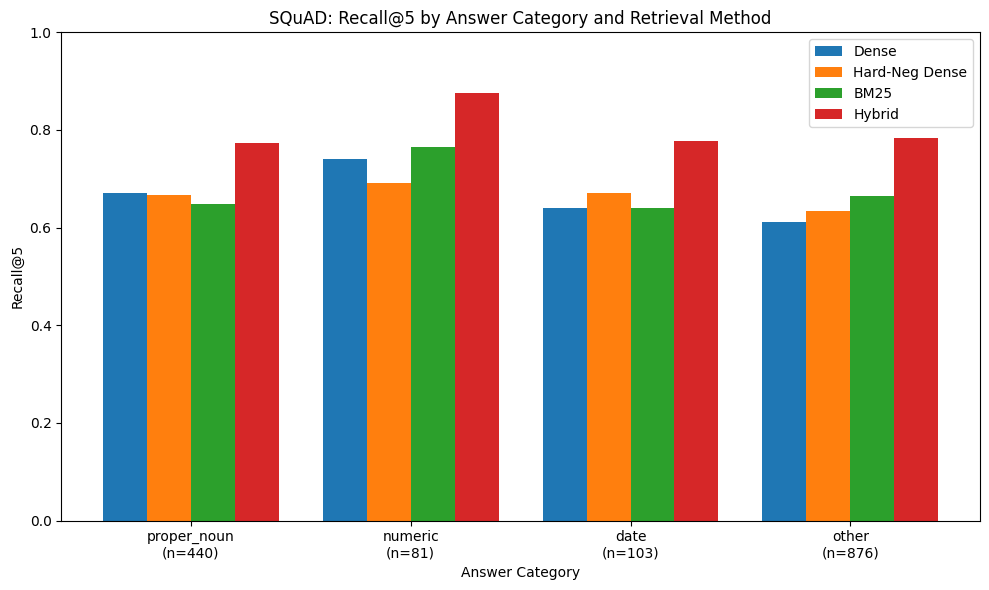

>>> Saved chart to /kaggle/working/dpr_rag_project/triviaqa/results/category_breakdown_chart.png


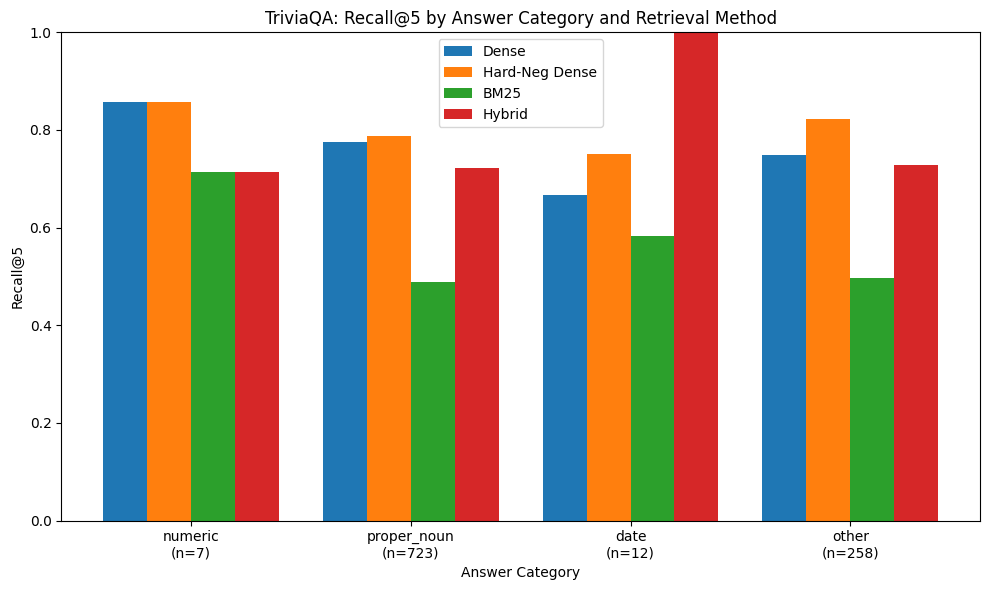

In [37]:
# Cell 31: Bar chart visualizing per-category Recall@5 across retrieval methods, both corpora

import matplotlib.pyplot as plt

def plot_category_breakdown(corpus_name, breakdown, k=5, save_path=None):
    categories = list(breakdown["dense"].keys())
    methods = ["dense", "hardneg", "bm25", "hybrid"]
    method_labels = ["Dense", "Hard-Neg Dense", "BM25", "Hybrid"]

    x = np.arange(len(categories))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (method, label) in enumerate(zip(methods, method_labels)):
        values = [breakdown[method][cat][k] for cat in categories]
        ax.bar(x + i * width, values, width, label=label)

    ax.set_xlabel("Answer Category")
    ax.set_ylabel(f"Recall@{k}")
    ax.set_title(f"{corpus_name}: Recall@{k} by Answer Category and Retrieval Method")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([f"{cat}\n(n={breakdown['dense'][cat]['_count']})" for cat in categories])
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f">>> Saved chart to {save_path}")
    plt.show()

plot_category_breakdown("SQuAD", squad_breakdown, k=5, save_path=f"{SQUAD_DIR}/results/category_breakdown_chart.png")
plot_category_breakdown("TriviaQA", trivia_breakdown, k=5, save_path=f"{TRIVIAQA_DIR}/results/category_breakdown_chart.png")

In [38]:
# Cell 32: Single callable function — question in, full RAG answer out
# Supports: corpus selection (squad/triviaqa) and retrieval mode (dense/hardneg/bm25/hybrid)

CORPUS_REGISTRY = {
    "squad": {
        "question_encoder": squad_question_encoder,
        "hardneg_question_encoder": squad_hardneg_q_enc,
        "index": squad_index,
        "hardneg_index": squad_hardneg_index,
        "passages": squad_passages,
        "bm25": squad_bm25,
    },
    "triviaqa": {
        "question_encoder": trivia_question_encoder,
        "hardneg_question_encoder": trivia_hardneg_q_enc,
        "index": trivia_index,
        "hardneg_index": trivia_hardneg_index,
        "passages": trivia_passages,
        "bm25": trivia_bm25,
    },
}

def rag_pipeline(question, corpus="squad", retrieval_mode="hybrid", k=3, alpha=0.5,
                  max_new_tokens=32, verbose=True):
    """
    Full end-to-end pipeline: question -> retrieve -> generate.

    corpus: "squad" or "triviaqa"
    retrieval_mode: "dense", "hardneg", "bm25", or "hybrid"
    """
    if corpus not in CORPUS_REGISTRY:
        raise ValueError(f"corpus must be one of {list(CORPUS_REGISTRY.keys())}")
    reg = CORPUS_REGISTRY[corpus]

    if retrieval_mode == "dense":
        retrieved = dense_retrieve(question, reg["question_encoder"], reg["index"], reg["passages"], k=k)
    elif retrieval_mode == "hardneg":
        retrieved = dense_retrieve(question, reg["hardneg_question_encoder"], reg["hardneg_index"], reg["passages"], k=k)
    elif retrieval_mode == "bm25":
        retrieved = hybrid_retrieve(question, reg["question_encoder"], reg["index"], reg["passages"], reg["bm25"], k=k, alpha=0.0)
    elif retrieval_mode == "hybrid":
        retrieved = hybrid_retrieve(question, reg["question_encoder"], reg["index"], reg["passages"], reg["bm25"], k=k, alpha=alpha)
    else:
        raise ValueError("retrieval_mode must be 'dense', 'hardneg', 'bm25', or 'hybrid'")

    fid_input = build_fid_input(question, retrieved)
    inputs = gen_tokenizer(fid_input, return_tensors="pt", truncation=True, max_length=512).to(device)

    generator.eval()
    with torch.no_grad():
        output_ids = generator.generate(
            inputs["input_ids"], attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens, num_beams=4, early_stopping=True
        )
    answer = gen_tokenizer.decode(output_ids[0], skip_special_tokens=True)

    if verbose:
        print(f"Corpus: {corpus} | Retrieval mode: {retrieval_mode} (k={k})")
        print(f"Question: {question}")
        print(f"Top retrieved passage: {retrieved[0]['text'][:150]}...")
        print(f"Generated answer: {answer}")

    return {
        "question": question, "answer": answer, "corpus": corpus,
        "retrieval_mode": retrieval_mode, "retrieved_passages": retrieved
    }

# Quick smoke test across both corpora and a couple of modes
print("="*70)
rag_pipeline("Who wrote the theory of relativity?", corpus="squad", retrieval_mode="hybrid")
print()
rag_pipeline("Who wrote the theory of relativity?", corpus="triviaqa", retrieval_mode="hybrid")
print("="*70)

Corpus: squad | Retrieval mode: hybrid (k=3)
Question: Who wrote the theory of relativity?
Top retrieved passage: The convergence of these various sources into a uniform theory of groups started with Camille Jordan's Traité des substitutions et des équations algéb...
Generated answer: Albert Einstein

Corpus: triviaqa | Retrieval mode: hybrid (k=3)
Question: Who wrote the theory of relativity?
Top retrieved passage: The theory of relativity usually encompasses two theories by Albert Einstein: special relativity and general relativity. Concepts introduced by the th...
Generated answer: Albert Einstein


In [39]:
# Cell 33: Pull every saved result file (both corpora, all methods) into one master summary

def safe_load(path):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    print(f"Warning: {path} not found — skipping.")
    return None

def load_corpus_results(corpus_name, work_dir):
    return {
        "dense_recall": safe_load(f"{work_dir}/results/dense_recall.json"),
        "hybrid_recall": safe_load(f"{work_dir}/results/hybrid_recall.json"),
        "hardneg_recall": safe_load(f"{work_dir}/results/hardneg_dense_recall.json"),
        "alpha_ablation": safe_load(f"{work_dir}/results/alpha_ablation.json"),
        "generation_eval": safe_load(f"{work_dir}/results/generation_eval.json"),
        "hardneg_generation_eval": safe_load(f"{work_dir}/results/hardneg_generation_eval.json"),
        "category_breakdown": safe_load(f"{work_dir}/results/category_breakdown.json"),
    }

squad_results = load_corpus_results("SQuAD", SQUAD_DIR)
trivia_results = load_corpus_results("TriviaQA", TRIVIAQA_DIR)

print("="*75)
print("MAJOR 1 — DENSE RETRIEVAL + RAG: FULL PROJECT SUMMARY")
print("="*75)
print(f"\nCorpora: SQuAD ({len(squad_passages)} passages) | TriviaQA ({len(trivia_passages)} passages)")
print(f"Retriever: bert-base-uncased dual encoder (baseline + hard-negative variants)")
print(f"Generator: t5-base, FiD-style")

for corpus_name, results in [("SQuAD", squad_results), ("TriviaQA", trivia_results)]:
    print(f"\n{'='*75}\n{corpus_name}\n{'='*75}")

    if results["dense_recall"] and results["hybrid_recall"] and results["hardneg_recall"]:
        print(f"\n--- Recall@k: Dense vs Hard-Neg-Dense vs Hybrid ---")
        print(f"{'k':<8}{'Dense':<10}{'HardNeg':<10}{'Hybrid':<10}")
        for k in ["1", "5", "20", "100"]:
            d = results["dense_recall"].get(k, results["dense_recall"].get(int(k)))
            hn = results["hardneg_recall"].get(k, results["hardneg_recall"].get(int(k)))
            h = results["hybrid_recall"].get(k, results["hybrid_recall"].get(int(k)))
            print(f"{k:<8}{d:<10.4f}{hn:<10.4f}{h:<10.4f}")

    if results["generation_eval"] and results["hardneg_generation_eval"]:
        print(f"\n--- Generation EM/F1: Dense vs Hard-Neg vs Hybrid ---")
        ge = results["generation_eval"]
        hge = results["hardneg_generation_eval"]
        print(f"{'Metric':<8}{'Dense':<10}{'HardNeg':<10}{'Hybrid':<10}")
        print(f"{'EM':<8}{ge['dense']['EM']:<10.4f}{hge['EM']:<10.4f}{ge['hybrid']['EM']:<10.4f}")
        print(f"{'F1':<8}{ge['dense']['F1']:<10.4f}{hge['F1']:<10.4f}{ge['hybrid']['F1']:<10.4f}")

    if results["category_breakdown"]:
        print(f"\n--- Recall@5 by Answer Category (Dense / HardNeg / BM25 / Hybrid) ---")
        bd = results["category_breakdown"]
        for cat in bd["dense"]:
            n = bd["dense"][cat]["_count"]
            d = bd["dense"][cat]["5"] if "5" in bd["dense"][cat] else bd["dense"][cat].get(5)
            hn = bd["hardneg"][cat]["5"] if "5" in bd["hardneg"][cat] else bd["hardneg"][cat].get(5)
            b = bd["bm25"][cat]["5"] if "5" in bd["bm25"][cat] else bd["bm25"][cat].get(5)
            h = bd["hybrid"][cat]["5"] if "5" in bd["hybrid"][cat] else bd["hybrid"][cat].get(5)
            print(f"  {cat:<15} (n={n:<5}) Dense={d:.3f}  HardNeg={hn:.3f}  BM25={b:.3f}  Hybrid={h:.3f}")

print("\n" + "="*75)
print("Artifacts saved under:", BASE_WORK_DIR)
print("="*75)

# Save master summary
master_summary = {"squad": squad_results, "triviaqa": trivia_results}
with open(f"{BASE_WORK_DIR}/final_master_summary.json", "w") as f:
    json.dump(master_summary, f, indent=2)
print("\n>>> Saved final_master_summary.json")

MAJOR 1 — DENSE RETRIEVAL + RAG: FULL PROJECT SUMMARY

Corpora: SQuAD (18890 passages) | TriviaQA (21111 passages)
Retriever: bert-base-uncased dual encoder (baseline + hard-negative variants)
Generator: t5-base, FiD-style

SQuAD

--- Recall@k: Dense vs Hard-Neg-Dense vs Hybrid ---
k       Dense     HardNeg   Hybrid    
1       0.3773    0.3893    0.5873    
5       0.6380    0.6487    0.7847    
20      0.8127    0.8140    0.8967    
100     0.9353    0.9360    0.9540    

--- Generation EM/F1: Dense vs Hard-Neg vs Hybrid ---
Metric  Dense     HardNeg   Hybrid    
EM      0.4350    0.4300    0.5500    
F1      0.5159    0.5088    0.6411    

--- Recall@5 by Answer Category (Dense / HardNeg / BM25 / Hybrid) ---
  proper_noun     (n=440  ) Dense=0.670  HardNeg=0.666  BM25=0.648  Hybrid=0.773
  numeric         (n=81   ) Dense=0.741  HardNeg=0.691  BM25=0.765  Hybrid=0.877
  date            (n=103  ) Dense=0.641  HardNeg=0.670  BM25=0.641  Hybrid=0.777
  other           (n=876  ) Dense=0.